In [1]:
%pip install neurokit2

Note: you may need to restart the kernel to use updated packages.


Record shape: (61000, 3)
PPG: (61000,)
ABP: (61000,)
ECG: (61000,)
PPG windows: (97, 625)
ECG windows: (97, 625)
ABP windows: (97, 625)


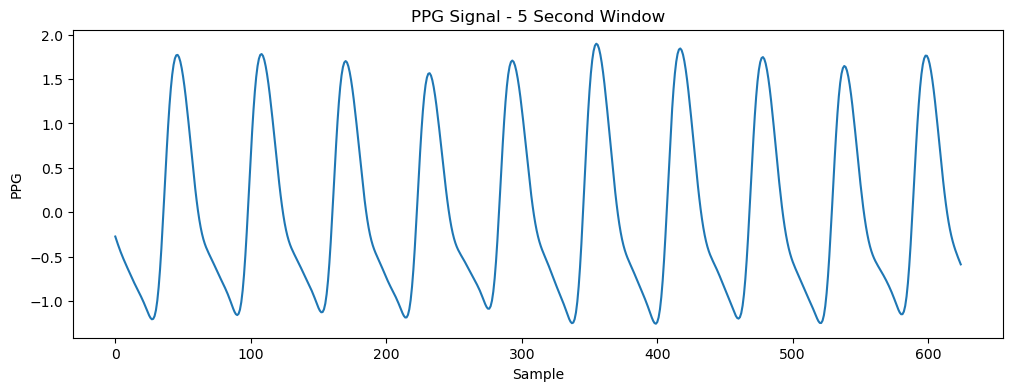

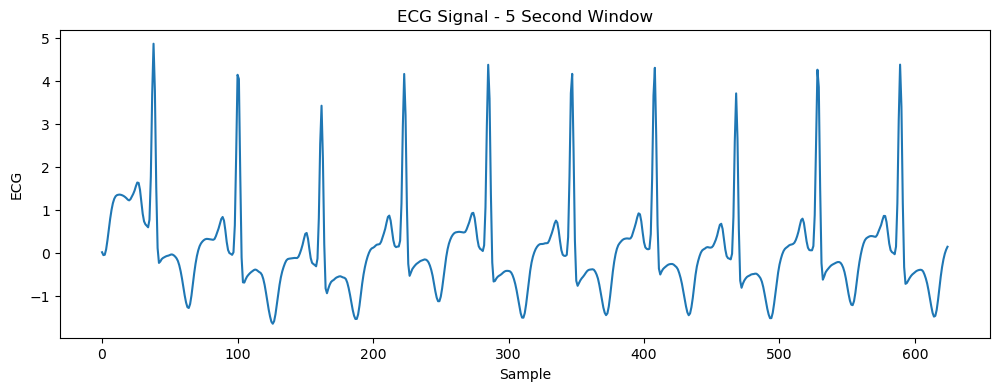

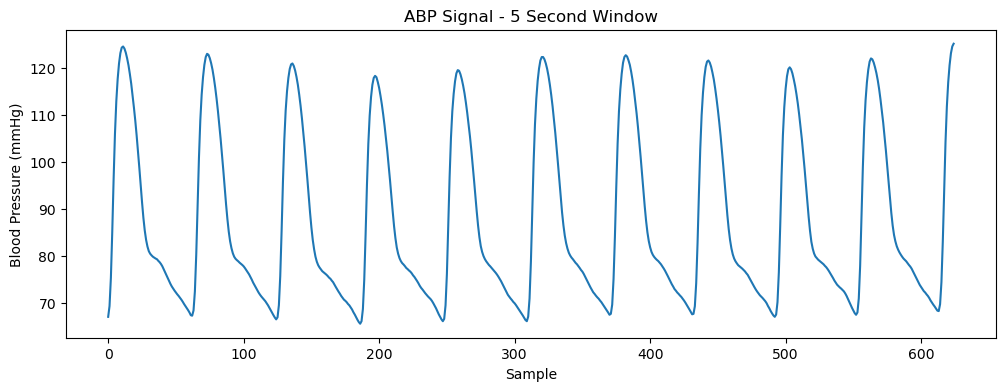

In [2]:
import h5py
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt

#Load data 
file_path = "data/cuff+less+blood+pressure+estimation/Part_1.mat"

with h5py.File(file_path, "r") as f:
    data = f["Part_1"]

    ref = data[0, 0]
    record = np.array(f[ref])


#Get signals
print("Record shape:", record.shape)
# If rows are samples and columns are signals
if record.shape[1] == 3:
    ppg = record[:, 0]
    abp = record[:, 1]
    ecg = record[:, 2]

# If rows are signals and columns are samples
else:
    ppg = record[0]
    abp = record[1]
    ecg = record[2]

print("PPG:", ppg.shape)
print("ABP:", abp.shape)
print("ECG:", ecg.shape)


#Remove bad values
ppg = np.nan_to_num(ppg)
abp = np.nan_to_num(abp)
ecg = np.nan_to_num(ecg)


#Clean signals
sampling_rate = 125

ppg_clean = nk.ppg_clean(
    ppg,
    sampling_rate=sampling_rate
)

ecg_clean = nk.ecg_clean(
    ecg,
    sampling_rate=sampling_rate
)


#Normalize
def normalize(signal):
    return (signal - np.mean(signal)) / np.std(signal)

ppg_clean = normalize(ppg_clean)
ecg_clean = normalize(ecg_clean)


#Make 5-second windows
sampling_rate = 125
window_size = sampling_rate * 5

ppg_windows = []
ecg_windows = []
abp_windows = []

for start in range(0, len(ppg_clean) - window_size, window_size):
    end = start + window_size

    ppg_windows.append(ppg_clean[start:end])
    ecg_windows.append(ecg_clean[start:end])
    abp_windows.append(abp[start:end])

ppg_windows = np.array(ppg_windows)
ecg_windows = np.array(ecg_windows)
abp_windows = np.array(abp_windows)

print("PPG windows:", ppg_windows.shape)
print("ECG windows:", ecg_windows.shape)
print("ABP windows:", abp_windows.shape)


#Graphs
window = 0

#PPG
plt.figure(figsize=(12, 4))
plt.plot(ppg_windows[window])
plt.title("PPG Signal - 5 Second Window")
plt.xlabel("Sample")
plt.ylabel("PPG")
plt.show()

#ECG
plt.figure(figsize=(12, 4))
plt.plot(ecg_windows[window])
plt.title("ECG Signal - 5 Second Window")
plt.xlabel("Sample")
plt.ylabel("ECG")
plt.show()

#ABP
plt.figure(figsize=(12, 4))
plt.plot(abp_windows[window])
plt.title("ABP Signal - 5 Second Window")
plt.xlabel("Sample")
plt.ylabel("Blood Pressure (mmHg)")
plt.show()